In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, json
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

## Repeatable Figure Generation and XAP Clustering Analysis

#### Create mean embeddings

In [ ]:
# load data here as mlp
mlp = ad.read_h5ad('/scratch/users/samutiti/U54/SubCellNuc/training_V07/inference_U2OS.h5ad')
print(mlp)

AnnData object with n_obs × n_vars = 293106 × 1280
    obs: 'gene_name', 'gene_idx', 'locations', 'atlas_name'
    obsm: 'h'


In [13]:
def mean_embeddings_by_gene_with_loc(embeddings: np.ndarray, df: pd.DataFrame):
    """
    Compute mean embedding per gene_name and return the first localization.

    Parameters
    ----------
    embeddings : np.ndarray
        Shape (N, D)
    df : pd.DataFrame
        Must contain columns:
            - 'gene_names'
            - 'locations'

    Returns
    -------
    gene_means : np.ndarray
        Shape (G, D)
    unique_genes : np.ndarray
        Gene names aligned to gene_means
    gene_localizations : np.ndarray
        First localization per gene, aligned to gene_means
    """

    if len(embeddings) != len(df):
        raise ValueError("Embeddings and dataframe must have the same number of rows.")

    # Extract first localization (before comma) efficiently
    first_locs = df["locations"].str.split(",").str[0].values

    # Factorize genes (preserves order of first appearance)
    labels, unique_genes = pd.factorize(df["gene_name"])
    n_genes = len(unique_genes)

    # Sum embeddings per gene
    gene_sums = np.zeros((n_genes, embeddings.shape[1]), dtype=np.float32)
    np.add.at(gene_sums, labels, embeddings)

    # Count per gene
    counts = np.bincount(labels).reshape(-1, 1)

    gene_means = gene_sums / counts

    # Get first localization per gene (aligned to factorization order)
    first_loc_per_gene = pd.Series(first_locs).groupby(labels).first().values
    data_df = pd.DataFrame({
        'gene': unique_genes,
        'loc': first_loc_per_gene
    })

    return gene_means, data_df

In [14]:
def make_mean_df(adata):
    df = adata.obs
    embeddings = adata.X
    df_expanded = df.assign(gene_names=df["gene_name"].str.split(",")).explode("gene_name")
    # embeddings_expanded = np.repeat(embeddings, df["gene_name"].str.count(",") + 1, axis=0)
    embeddings_expanded = embeddings

    gene_means, data_df = mean_embeddings_by_gene_with_loc(embeddings_expanded, df_expanded)
    new_adata = ad.AnnData(X=gene_means, obs=data_df)
    return new_adata

In [15]:
mean_mlpv7_u2OS = make_mean_df(mlp)
print(mean_mlpv7_u2OS)

AnnData object with n_obs × n_vars = 669 × 1280
    obs: 'gene', 'loc'


/share/software/user/open/python/3.12.1/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### Load Data and Visualize

##### load data

In [3]:
# load mlp
load_dir = '/scratch/users/samutiti/U54/SubCellNuc/training_V05/'
load_file = 'U2OS_mean_inference_analyzed.h5ad'
mlp_data = ad.read_h5ad(f'{load_dir}/{load_file}')
print(mlp_data)

AnnData object with n_obs × n_vars = 10972 × 1280
    obs: 'gene', 'loc', 'leiden_0.3', 'umap_x', 'umap_y', 'XAP'
    uns: 'leiden_0.3', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


#### Add XAP labels

In [49]:
### Color By XAP
# Normalize function
def normalize_gene(g):
    return g.replace("-", "").replace("_", "").strip().upper()

# Build a normalized lookup set once
xap_set_normalized = {normalize_gene(g) for g in {
"HMGB1", "ILF2", "XRN2", "POLDIP3", "RNF20", "FUBP3", "HNRPLL", "ILF3",
"SSB", "SRRT", "EIF4A3", "RNMT", "PTBP2", "SAP18", "WTAP", "KHDRBS1",
"ERH", "CIZ1", "HNRNPH3", "SYNCRIP", "NONO", "FUS", "DHX9", "RALY",
"DDX17", "HNRPDL", "KHSRP", "RNF2", "HNRNPA3", "HNRNPUL2", "HNRNPD",
"DDX5", "DDX39B", "PTBP1", "HNRNPR", "ZFR", "ELAVL1", "SRSF2",
"HNRNPM", "RBMXL1", "TARDBP", "MYEF2", "HNRNPU", "HNRNPC",
"HNRNPL", "HNRNPAB", "HNRNPK", "HNRNPA2B1", "HNRNPA1",
"HNRNPA0", "RBM14", "TRA2B", "SFPQ", "IGF2BP1", "SARNP",
"SRSF3", "MATR3", "SRSF5", "SPEN", "RBM15", "RBM3",
"SRSF7", "RBFOX2", "SRSF9", "SAFB", "THOC4", "DDX39A",
"CELF1", "PCGF5", "RYBP", "TRIM71", "SRSF10", "RBM4",
"YTHDC1", "TRIM6", "LIN28A", "SLTM", "SAFB2", "L1TD1",
"MYBBP1A", "IGF2BP3"
}}

def is_xap(genes):
    genes = genes.replace(' ', '').split(',')
    for gene in genes:
        if normalize_gene(gene) in xap_set_normalized:
            return 'XAPs'
    return 'Other Proteins' 

# u2os_df['XAP'] = [is_xap_acc(g) for g in u2os_df['gene']]
xaps = [is_xap(g) for g in mlp_data.obs['gene']] # these should be atlas names
mlp_data.obs['XAP'] = xaps
if len(np.unique(mlp_data.obs['XAP'])) < 2:
    raise ValueError('XAPs not properly assigned')
mlp_data.write_h5ad(f'{load_dir}/{load_file}')

#### Visualize

In [5]:
mlp_df = mlp_data.obs
dataframe = mlp_df
print(dataframe.columns)

dataframe = dataframe.sort_values(by='XAP')
print(dataframe)
# dataframe = dataframe.sort_values(by='loc')

Index(['gene', 'loc', 'leiden_0.3', 'umap_x', 'umap_y', 'XAP'], dtype='object')
                           gene              loc leiden_0.3    umap_x  \
0                        GPR173  Golgi apparatus          0  4.739308   
7297                      FOXQ1         Vesicles          3  0.206826   
7298                    TAX1BP3          Cytosol          3  0.509107   
7299                      ACYP2          Cytosol          3  0.750615   
7300                      MTHFS      Nucleoplasm          3  1.866197   
...                         ...              ...        ...       ...   
7309  HMGB1,HMGB1P1,HMGB2,HMGB3          Cytosol          4 -0.379511   
6622                     HNRNPK     Mitochondria          4 -0.917082   
2195                       RBM3  Golgi apparatus          2  6.513105   
3332                     HNRNPM   Cell Junctions          1  2.811540   
912                       FUBP3      Nucleoplasm          1  3.515553   

         umap_y             XAP  
0     21.

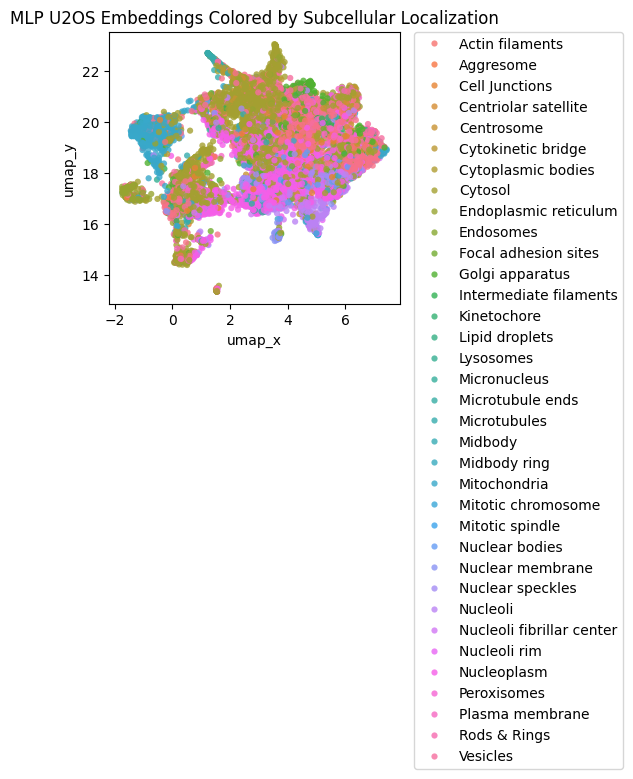

In [11]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=dataframe,
    x="umap_x", # may need to change to 'x'
    y="umap_y", # may need to change to 'y'
    hue="loc",
    # palette=["gray", "red"],
    # palette='hls',
    # size='XAP',
    # sizes={'XAPs':5, 'Other Proteins':1}, # 20, 5 OR 5, 1
    s=20,
    alpha=0.8,
    linewidth=0
)

plt.title("MLP U2OS Embeddings Colored by Subcellular Localization")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
# plt.gca().get_legend().remove() # remove ugly legends
plt.tight_layout()
plt.show()

In [ ]:
# u2os_data_for_analysis = (u2os_emb, u2os_df[['gene']]) # more efficient storage
mlp_df = mean_mlpv5_u2OS.obs
print(mlp_df.columns)
mlp_data_for_analysis = (mean_mlpv5_u2OS.X, mlp_df)

torch.save(mlp_data_for_analysis, 'mlp_data_v5_mean_u2os_only.pth')

Index(['gene', 'loc'], dtype='object')


In [39]:
! python /scratch/users/samutiti/U54/SubCellNuc/eval/asees_xap_in_embeddings.py mlp_data_v5_mean_u2os_only.pth

Total samples: 10972
XAP samples: 96
Non-XAP samples: 10876

Computing similarities without full matrix...
